# Informal Settlement Classification (Nairobi) — pixel-based RF

## Approach: background sampling + probability smoothing, no masking, no SNIC

Earlier attempts over-detected (flagging Nairobi National Park, savanna and
formal estates) and the segmentation step timed out. Two root causes, two fixes:

1. **Narrow negative class** → the *informal* class was labelled precisely but
   *not-informal* was only ~30 hand-picked spots, so savanna was
   out-of-distribution and the RF guessed informal.
   **Fix:** sample negatives as random **background points across the whole
   city** — the model now sees park / savanna / formal / industrial as
   not-informal and rejects them itself. No masks.

2. **SNIC segmentation over the whole city** was the cost that timed out, and
   mixed three resolutions for no reason.
   **Fix:** drop SNIC. Classify **per pixel** (texture features already encode
   ~70 m context), then **smooth the output probability** for clean regions.

## Pipeline

```
1. Sentinel-2 dry-season (Jun-Sep) median composite, 18 features (10 m)
2. Random Forest (150 trees):
     positives = informal polygons
     negatives = background points across all of Nairobi (+ your formal polygons)
3. MULTIPROBABILITY -> P(informal) per pixel   (arrayGet([0]))
4. Focal-mean smooth P(informal) (~30 m) -> threshold >= CONFIDENCE_THRESHOLD
5. Vectorize, filter by area [MIN_AREA_HA, MAX_AREA_HA], export GeoJSON
```

A diagnostic (Section 6) checks that P(informal) is high inside your informal
zones and low inside not-informal zones before you trust the map.


---
## 0 - Setup


In [1]:
import os
import sys
import json
import glob
import re
import shutil
import time

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import ee

sys.path.append('../.')
from src.settlement_classifier import (
    CLASS_NAMES, CLASS_COLORS, FEATURE_BANDS,
    build_feature_composite, load_training_zones,
    evaluate_accuracy, visualize_confusion_matrix, visualize_feature_importance,
    _get_thumb, _get_extent, _draw_boundary,
)

try:
    ee.Initialize()
except Exception:
    ee.Authenticate(auth_mode='localhost')
    ee.Initialize(project='ee-nairobi-heatmap')

print('Earth Engine initialised.')
print(f'Classes      : {CLASS_NAMES}')
print(f'Features ({len(FEATURE_BANDS)}): {FEATURE_BANDS}')

Earth Engine initialised.
Classes      : ['informal', 'not-informal']
Features (18): ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'BSI', 'SAVI', 'EVI', 'B4_asm', 'B4_contrast', 'B4_ent', 'B4_idm', 'B4_corr']


### Static map helper

The interactive geemap widgets did not render, so all maps below are drawn as
static matplotlib thumbnails fetched server-side from Earth Engine.


In [2]:
def show_layer(ee_img, vis, title, roi, ax=None, dimensions=1024, draw_boundary=True):
    """Render an Earth Engine image as a static matplotlib thumbnail."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(11, 9))
    try:
        img = _get_thumb(ee_img, roi, vis, dimensions=dimensions)
        extent = _get_extent(roi)
        ax.imshow(img, extent=extent)
        if draw_boundary:
            _draw_boundary(ax, roi)
    except Exception as e:
        print(f'Thumbnail error: {e}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')
    if own_fig:
        plt.tight_layout()
        plt.show()
    return ax


---
## 1 - Configuration

### Main tuning knobs

| Parameter | Default | Role |
|-----------|---------|------|
| `CONFIDENCE_THRESHOLD` | **0.68** | A pixel is informal if smoothed `P(informal) >=` this. An high treshold like this one allow us to be more sure that we are dealing with informal settlements. |
| `SMOOTH_RADIUS_PX` | **3** | Focal-mean radius (10 m pixels) on the probability. Higher = smoother blobs. |
| `N_BACKGROUND` | **6000** | Random background (not-informal) points sampled across the city. |
| `NEG_POS_RATIO` | **4.0** | Negatives per positive in the training set. |
| `N_TREES` | **150** | Number of Random Forest trees. |
| `MAX_AREA_HA` / `MIN_AREA_HA` | **150 / 12** | Drop polygons larger / smaller than this. |


In [ ]:
# -- Years --------------------------------------------------------------------
TRAINING_YEAR    = 2024
TRAINING_GEOJSON = '../data/geospatial/1_exposure/training_zones_v2.geojson'

# -- Model --------------------------------------------------------------------
# 150 trees is plenty - past ~100-150 accuracy barely moves and runtime grows
# linearly. (This is the number of TREES that vote, not tree depth.)
N_TREES   = 150
CLOUD_PCT = 20

# -- Confidence threshold (main tuning knob) ----------------------------------
# A pixel is informal if smoothed P(informal) >= this.
#   0.50 = neutral start; raise to 0.55-0.70 to cut false positives.
CONFIDENCE_THRESHOLD = 0.68

# -- Spatial coherence (replaces SNIC) ----------------------------------------
# We classify per pixel, then smooth the probability with a focal mean before
# thresholding. This removes salt-and-pepper noise and gives coherent blobs
# without the cost of segmentation. Radius in 10 m pixels (3 -> ~30 m window).
SMOOTH_RADIUS_PX = 3

# -- Negatives ----------------------------------------------------------------
# Positives = informal polygons. hand-drawn not-informal polygons (formal/
# other, incl. any formal hard-negatives added) are ALWAYS used in full.
#
# USE_BACKGROUND adds random background points across the city to fill up to the
# ratio - they teach the model what EMPTY land (park / savanna / bare) is.
#   True  -> robust against park/savanna over-detection (recommended)
#   False -> train only ontraining data made by hand. Faster, no pseudo-negative noise, BUT
#            the park may reappear unless polygons cover empty land too.
USE_BACKGROUND      = True
N_BACKGROUND        = 6000   # max random background points (fills up to ratio)
NEG_POS_RATIO       = 4.0    # target negatives : positives
BG_EXCLUDE_BUFFER_M = 50     # keep background points >= this far from informal

# -- Polygon size filters (post-processing) -----------------------------------
MIN_AREA_HA = 12.0
MAX_AREA_HA = 150.0

# -- Sampling & export --------------------------------------------------------
SAMPLE_SCALE  = 10   # native S2 resolution - pixel-based, no segmentation
EXPORT_SCALE  = 20   # raster->vector resolution
MAX_PER_CLASS = 5000

# -- Paths --------------------------------------------------------------------
WEBAPP_MAPS_DIR = '../webapp/public/maps'
RESULTS_DIR     = '../results/exposure'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(WEBAPP_MAPS_DIR, exist_ok=True)

print(f'Training year       : {TRAINING_YEAR}')
print(f'RF trees            : {N_TREES}')
print(f'Confidence threshold: P(informal) >= {CONFIDENCE_THRESHOLD}')
print(f'Smoothing radius    : {SMOOTH_RADIUS_PX} px (~{SMOOTH_RADIUS_PX * 10} m)')
print(f'Background sampling  : {USE_BACKGROUND}  ({N_BACKGROUND:,} pts max, neg:pos {NEG_POS_RATIO})')
print(f'Area filter         : [{MIN_AREA_HA}, {MAX_AREA_HA}] ha')

Training year       : 2024
RF trees            : 150
Confidence threshold: P(informal) >= 0.68
Smoothing radius    : 3 px (~30 m)
Background sampling  : True  (6,000 pts max, neg:pos 4.0)
Area filter         : [12.0, 150.0] ha


---
## 2 - Load Nairobi boundary


In [4]:
nairobi_boundary = (
    ee.FeatureCollection('projects/ee-nairobi-heatmap/assets/ken_admin2')
    .filter(ee.Filter.eq('adm1_name', 'Nairobi'))
)
print('Boundary loaded.')


Boundary loaded.


---
## 3 - Sentinel-2 composite (dry season)

Median of June-September to avoid wet-season greening / flooding artefacts.


In [5]:
print(f'[1/6] Building Sentinel-2 composite for {TRAINING_YEAR} (Jun-Sep)...')
composite = build_feature_composite(nairobi_boundary, TRAINING_YEAR, CLOUD_PCT)
print(f'  Bands available: {composite.bandNames().getInfo()}')


[1/6] Building Sentinel-2 composite for 2024 (Jun-Sep)...
  [Loading Sentinel-2 composite for 2024]
  [Computing spectral indices]
  [Computing GLCM texture features]
  Bands available: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'BSI', 'SAVI', 'EVI', 'B4_asm', 'B4_contrast', 'B4_ent', 'B4_idm', 'B4_corr']


---
## 4 - Feature image (pixel-based, no segmentation)

We work directly on the 18-band composite at 10 m. There is **no SNIC
segmentation** — it was the main cost (segmenting the whole city interactively
caused the Section 5 timeout) and added a confusing scale mismatch.

Spatial context is already baked into the features: the GLCM texture is computed
over a 7×7 window (~70 m), so each pixel "sees" whether it sits in a chaotic
roofscape. We recover clean, coherent regions later by smoothing the *output
probability* (Section 7), which is far cheaper than segmenting the input.


In [6]:
# Pixel-based feature image: just the 18 model bands from the composite.
feature_img = composite.select(FEATURE_BANDS)
print(f'Feature image ready ({len(FEATURE_BANDS)} bands, 10 m, no segmentation).')
print(f'  Bands: {feature_img.bandNames().getInfo()}')

Feature image ready (18 bands, 10 m, no segmentation).
  Bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'BSI', 'SAVI', 'EVI', 'B4_asm', 'B4_contrast', 'B4_ent', 'B4_idm', 'B4_corr']


---
## 5 - Sample training data & train the Random Forest

**Positives** — pixels inside your informal polygons.

**Negatives** — your hand-drawn not-informal polygons (formal/other) are
**always kept in full**, so any `formal` hard-negatives you add count fully and
are never diluted. If `USE_BACKGROUND = True`, random background points across
the city *fill the remainder* up to `NEG_POS_RATIO` — these teach the model what
empty land (park / savanna / bare) is. Set `USE_BACKGROUND = False` to train on
your polygons only.

Two classifiers are trained on the same data:
- `classifier` (CLASSIFICATION) -> metrics & feature importance
- `classifier_prob` (**MULTIPROBABILITY**) -> the `P(informal)` map


In [7]:
print('[1/4] Loading training zones...')
if not os.path.exists(TRAINING_GEOJSON):
    raise FileNotFoundError(f'GeoJSON not found: {TRAINING_GEOJSON}')
training_zones = load_training_zones(TRAINING_GEOJSON)
informal_zones = training_zones.filter(ee.Filter.eq('label', 0))

# -- POSITIVES: pixels inside your hand-drawn informal polygons ---------------
print('[2/4] Sampling POSITIVES (informal polygons)...')
pos_samples = (
    feature_img
    .sampleRegions(
        collection=informal_zones,
        properties=['label'],
        scale=SAMPLE_SCALE,
        tileScale=16,
        geometries=False,
    )
    .randomColumn('shuffle', seed=42)
    .sort('shuffle')
    .limit(MAX_PER_CLASS)
)
n_pos = pos_samples.size().getInfo()
print(f'  Informal (positive) samples : {n_pos:,}')

# -- NEGATIVES ----------------------------------------------------------------
# Total negatives are CAPPED at NEG_POS_RATIO x positives (else large drawn
# polygons -> hundreds of thousands of pixels -> RF memory limit). Polygon
# negatives are used first (subsampled if they exceed the cap); background fills
# any remainder only when USE_BACKGROUND is on.
print('[3/4] Sampling NEGATIVES...')
poly_neg = feature_img.sampleRegions(
    collection=training_zones.filter(ee.Filter.eq('label', 1)),
    properties=['label'],
    scale=SAMPLE_SCALE,
    tileScale=16,
    geometries=False,
)
n_poly_neg = poly_neg.size().getInfo()
target_neg = int(NEG_POS_RATIO * n_pos)
print(f'  Hand-drawn polygon negatives : {n_poly_neg:,}  (cap {target_neg:,})')

# Subsample polygon negatives to the cap (random).
poly_neg_capped = (
    poly_neg.randomColumn('negshuffle', seed=7).sort('negshuffle').limit(target_neg)
)

if USE_BACKGROUND and n_poly_neg < target_neg:
    n_bg_needed = target_neg - n_poly_neg
    informal_buffered = informal_zones.map(lambda f: f.buffer(BG_EXCLUDE_BUFFER_M))
    informal_raster   = ee.Image(0).paint(informal_buffered, 1)   # 1 inside informal(+buffer)
    outside_informal  = informal_raster.eq(0)
    neg_feature_img   = feature_img.updateMask(outside_informal)
    bg_samples = (
        neg_feature_img
        .sample(
            region=nairobi_boundary.geometry(),
            scale=SAMPLE_SCALE,
            numPixels=N_BACKGROUND,
            seed=42,
            tileScale=16,
            geometries=False,
        )
        .map(lambda f: f.set('label', 1))
        .limit(n_bg_needed)
    )
    neg_samples = poly_neg_capped.merge(bg_samples)
    print(f'  + background fill points     : up to {n_bg_needed:,} (USE_BACKGROUND=True)')
else:
    neg_samples = poly_neg_capped
    if USE_BACKGROUND:
        print('  Polygons already meet the cap - no background needed.')
    else:
        print('  Background DISABLED (USE_BACKGROUND=False) - polygons only.')

n_neg = neg_samples.size().getInfo()
print(f'  Total negative samples       : {n_neg:,}  (target {target_neg:,})')

if n_pos == 0 or n_neg == 0:
    raise RuntimeError('A class is empty! Check training_zones_v2.geojson.')

# -- Merge, 80/20 split -------------------------------------------------------
all_samples = pos_samples.merge(neg_samples).randomColumn('split', seed=99)
train_set = all_samples.filter(ee.Filter.lt('split', 0.8))
test_set  = all_samples.filter(ee.Filter.gte('split', 0.8))
print(f'  Train : {train_set.size().getInfo():,}   Test : {test_set.size().getInfo():,}')

print('[4/4] Training Random Forest...')
# CLASSIFICATION mode -> metrics, feature importance
classifier = (
    ee.Classifier.smileRandomForest(N_TREES)
    .train(features=train_set, classProperty='label', inputProperties=FEATURE_BANDS)
)
# MULTIPROBABILITY mode -> array [P(label=0), P(label=1)] = [P(informal), P(not-informal)]
classifier_prob = (
    ee.Classifier.smileRandomForest(N_TREES)
    .setOutputMode('MULTIPROBABILITY')
    .train(features=train_set, classProperty='label', inputProperties=FEATURE_BANDS)
)

print('  Training done.')
print('\n--- Test-set evaluation ---')
metrics = evaluate_accuracy(test_set, classifier)
print(f"  Overall Accuracy : {metrics['overall_accuracy']:.4f}")
print(f"  Kappa            : {metrics['kappa']:.4f}")
print(f"  Confusion matrix : {metrics['confusion_matrix']}")

[1/4] Loading training zones...
  [Loaded 91 training zone(s) from ../data/geospatial/1_exposure/training_zones_v2.geojson]
[2/4] Sampling POSITIVES (informal polygons)...
  Informal (positive) samples : 5,000
[3/4] Sampling NEGATIVES...
  Hand-drawn polygon negatives : 469,936  (cap 20,000)
  Polygons already meet the cap - no background needed.
  Total negative samples       : 20,000  (target 20,000)
  Train : 20,081   Test : 4,919
[4/4] Training Random Forest...
  Training done.

--- Test-set evaluation ---
  [Evaluating model on test set]
  [Overall Accuracy: 0.932 | Kappa: 0.788]
  Overall Accuracy : 0.9317
  Kappa            : 0.7881
  Confusion matrix : [[825, 134], [202, 3758]]


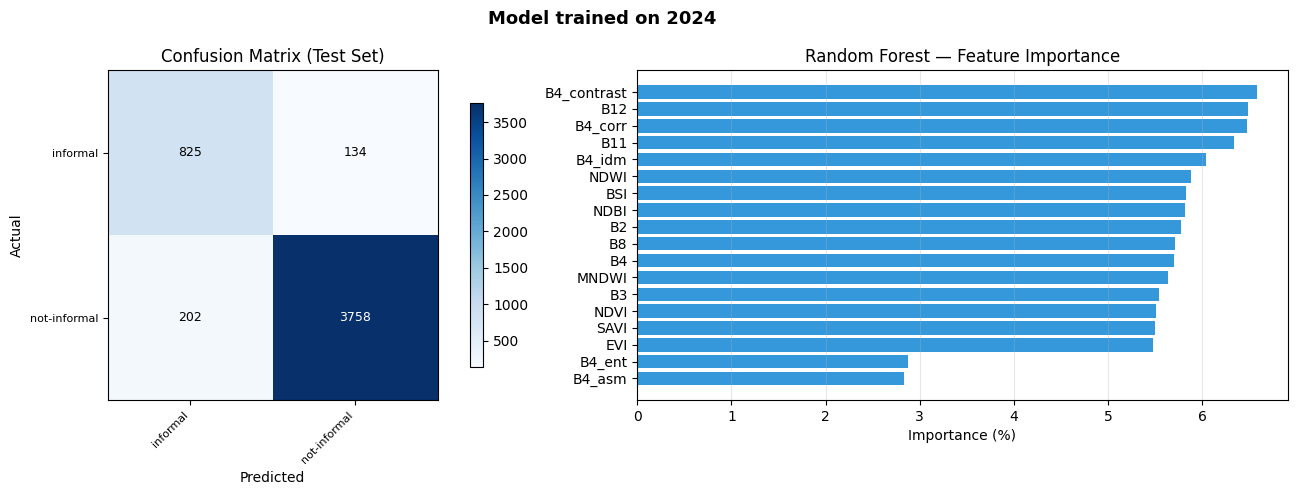

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
visualize_confusion_matrix(metrics, ax=axes[0])
visualize_feature_importance(classifier, ax=axes[1])
plt.suptitle(f'Model trained on {TRAINING_YEAR}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6 - P(informal) map + sanity-check diagnostic

`MULTIPROBABILITY` returns a per-pixel array ordered by ascending class value
`[P(0), P(1)]`. We take **index 0 = P(informal)** explicitly.

**Diagnostic.** Before trusting the map, measure the mean `P(informal)` *inside
the hand-labelled training polygons*:
- inside **informal** zones it should be **high**
- inside **not-informal** zones it should be **low**

If reversed, set `INVERT_PROB = True` in Section 7.


In [9]:
print('Computing P(informal) map (MULTIPROBABILITY, index 0)...')

# Per-pixel array of class probabilities, then pull index 0 = P(informal).
informal_prob = (
    feature_img
    .classify(classifier_prob)
    .arrayGet([0])
    .rename('informal_prob')
    .clip(nairobi_boundary)
)
print('  Probability map ready.')

# -- Sanity check: mean P(informal) inside each labelled class ----------------
prob_samples = informal_prob.sampleRegions(
    collection=training_zones,
    properties=['label'],
    scale=SAMPLE_SCALE,
    tileScale=16,
    geometries=False,
)
p_informal_zones = (
    prob_samples.filter(ee.Filter.eq('label', 0))
    .aggregate_mean('informal_prob').getInfo()
)
p_not_informal_zones = (
    prob_samples.filter(ee.Filter.eq('label', 1))
    .aggregate_mean('informal_prob').getInfo()
)

print('\n=== DIAGNOSTIC: mean P(informal) inside training polygons ===')
print(f'  Inside INFORMAL zones     : {p_informal_zones:.3f}   (should be HIGH)')
print(f'  Inside NOT-INFORMAL zones : {p_not_informal_zones:.3f}   (should be LOW)')
if p_informal_zones is not None and p_not_informal_zones is not None:
    if p_informal_zones > p_not_informal_zones:
        print('  OK -> class order correct. Keep INVERT_PROB = False in Section 7.')
    else:
        print('  REVERSED -> set INVERT_PROB = True in Section 7 and re-run 7-9.')

Computing P(informal) map (MULTIPROBABILITY, index 0)...
  Probability map ready.

=== DIAGNOSTIC: mean P(informal) inside training polygons ===
  Inside INFORMAL zones     : 0.765   (should be HIGH)
  Inside NOT-INFORMAL zones : 0.066   (should be LOW)
  OK -> class order correct. Keep INVERT_PROB = False in Section 7.


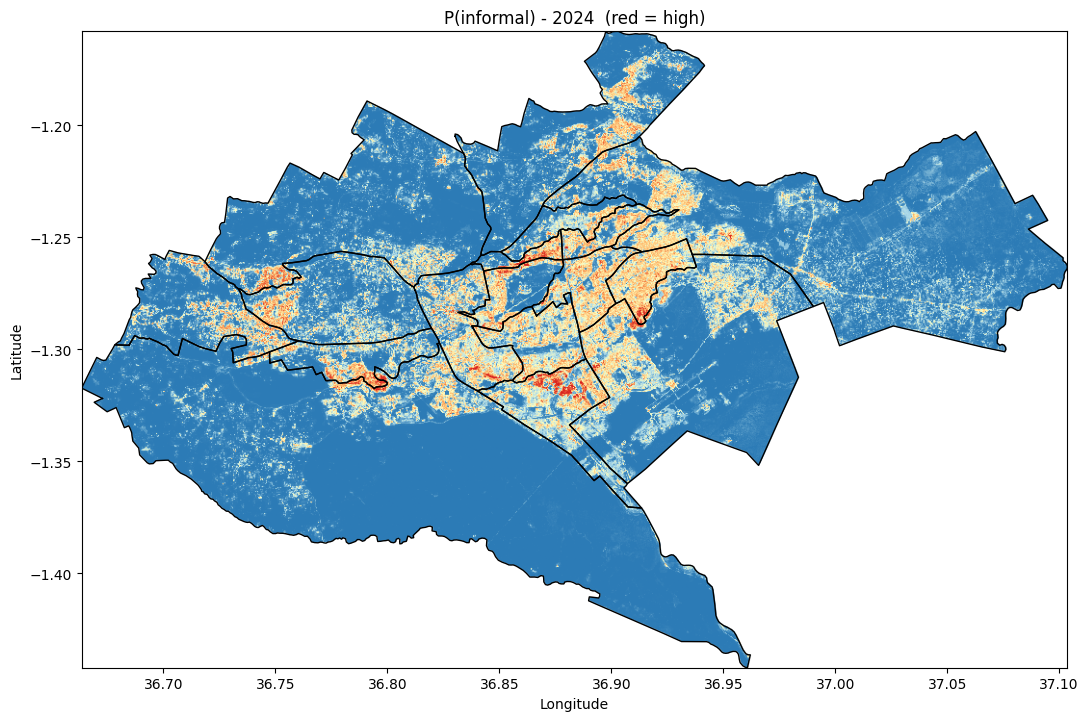

<Axes: title={'center': 'P(informal) - 2024  (red = high)'}, xlabel='Longitude', ylabel='Latitude'>

In [10]:
# Static thumbnail of the probability surface.
# Blue = low P(informal), red = high P(informal).
prob_vis = {
    'min': 0.0, 
    'max': 1.0,
    'palette': ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c'],
}
show_layer(informal_prob, prob_vis,
           f'P(informal) - {TRAINING_YEAR}  (red = high)', nairobi_boundary)


---
## 7 - Predict, smooth, threshold

```
1. P(informal) per pixel        (from the RF)
2. focal-mean smooth (~30 m)     -> coherent blobs, no salt-and-pepper
3. keep informal where smoothed P(informal) >= CONFIDENCE_THRESHOLD
```

The focal-mean smoothing is what replaces SNIC: it gives clean regions at a
fraction of the cost, and only at the output stage. No spectral/built-up masks.

> If the Section 6 diagnostic printed a WARNING (reversed classes), set
> `INVERT_PROB = True` below.


In [11]:
# Section 6 diagnostic confirms arrayGet([0]) is P(informal) on this setup.
# Flip to True only if a future run's diagnostic comes out reversed.
INVERT_PROB = False


def to_informal_prob(feat_img):
    """Return per-pixel P(informal), honouring INVERT_PROB."""
    p = feat_img.classify(classifier_prob).arrayGet([0]).rename('informal_prob')
    if INVERT_PROB:
        p = ee.Image(1).subtract(p).rename('informal_prob')
    return p


def smooth_and_classify(prob_image, boundary,
                        confidence_threshold=CONFIDENCE_THRESHOLD,
                        smooth_px=SMOOTH_RADIUS_PX):
    """Smooth P(informal), threshold. 0 = informal, 1 = not-informal."""
    prob_smooth = prob_image.focal_mean(radius=smooth_px, units='pixels')
    is_informal = prob_smooth.gte(confidence_threshold)
    classified = (
        ee.Image(1)
        .where(is_informal, ee.Image(0))
        .rename('classification')
        .toByte()
        .clip(boundary)
    )
    return classified


def classify_year_obia(year, boundary, cloud_pct=CLOUD_PCT,
                       confidence_threshold=CONFIDENCE_THRESHOLD,
                       smooth_px=SMOOTH_RADIUS_PX):
    """Full pixel-based pipeline for one year -> (classified, prob) images."""
    print(f'  [{year}] Building composite...')
    comp = build_feature_composite(boundary, year, cloud_pct)
    fi = comp.select(FEATURE_BANDS)
    print(f'  [{year}] Predicting P(informal)...')
    prob_img = to_informal_prob(fi).clip(boundary)
    print(f'  [{year}] Smoothing + threshold {confidence_threshold}...')
    classified = smooth_and_classify(prob_img, boundary, confidence_threshold, smooth_px)
    return classified, prob_img


# Classify 2024 (reuse informal_prob from Section 6, honouring INVERT_PROB).
informal_prob = to_informal_prob(feature_img).clip(nairobi_boundary)
print(f'Classifying {TRAINING_YEAR} with threshold={CONFIDENCE_THRESHOLD}, '
      f'smooth={SMOOTH_RADIUS_PX}px...')
classified_2024 = smooth_and_classify(informal_prob, nairobi_boundary)
print('  Done.')

Classifying 2024 with threshold=0.68, smooth=3px...
  Done.


---
## 8 - Visualise the 2024 classification

Red = informal, green = not-informal. Compare with the Section 6 probability
map: the red areas should now sit on the dense, chaotic rooftops (Kibera,
Mukuru, Mathare), not on Karen villas or the airbase.


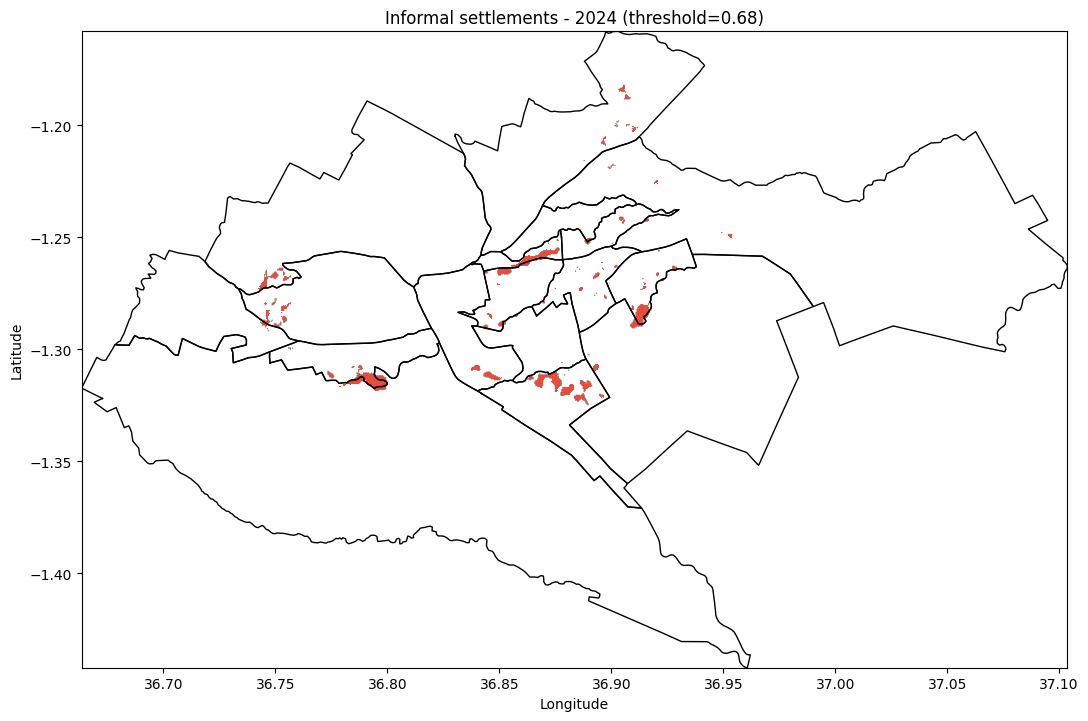

<Axes: title={'center': 'Informal settlements - 2024 (threshold=0.68)'}, xlabel='Longitude', ylabel='Latitude'>

In [12]:
# Show only the informal class (mask out not-informal so the basemap-less
# thumbnail stays readable); informal = red.
informal_only = classified_2024.updateMask(classified_2024.eq(0))
show_layer(
    informal_only,
    {'min': 0, 'max': 1, 'palette': ['#e74c3c', '#2ecc71']},
    f'Informal settlements - {TRAINING_YEAR} (threshold={CONFIDENCE_THRESHOLD})',
    nairobi_boundary,
)


---
## 8b - Interactive threshold explorer (optional)

Drag the slider to preview the informal map at different confidence levels.
Each release re-renders a static thumbnail (a few seconds), reusing the
probability already computed — no retraining, no GEE timeout.

Preview only: it does **not** change `CONFIDENCE_THRESHOLD` or export anything.
Once you settle on a value, set `CONFIDENCE_THRESHOLD` in Section 1 and re-run
Sections 7-9.


In [13]:
# import ipywidgets as widgets
# from IPython.display import display

# # Smoothed probability (identical to what Section 7 thresholds), computed once.
# prob_smooth = informal_prob.focal_mean(radius=SMOOTH_RADIUS_PX, units='pixels')

# thr_slider = widgets.FloatSlider(
#     value=CONFIDENCE_THRESHOLD, min=0.30, max=0.90, step=0.05,
#     description='Threshold:', continuous_update=False, readout_format='.2f',
#     layout=widgets.Layout(width='550px'),
# )
# out = widgets.Output()


# def render_threshold(thr):
#     """Re-threshold the existing probability and redraw a static thumbnail."""
#     with out:
#         out.clear_output(wait=True)
#         informal = prob_smooth.gte(thr).selfMask()   # informal pixels only
#         show_layer(
#             informal,
#             {'min': 0, 'max': 1, 'palette': ['#e74c3c']},
#             f'Informal pixels at threshold = {thr:.2f}',
#             nairobi_boundary,
#         )


# # Re-render whenever the slider is released (a few seconds per render).
# thr_slider.observe(
#     lambda ch: render_threshold(ch['new']) if ch['name'] == 'value' else None,
#     names='value',
# )

# display(thr_slider, out)
# render_threshold(thr_slider.value)
# print('Drag the slider (renders on release). When you find the value you like,')
# print('set CONFIDENCE_THRESHOLD in Section 1 to it and re-run Sections 7-9 to export.')

---
## 9 - Vectorise & export

Keep only class 0 (informal) polygons whose area is within
`[MIN_AREA_HA, MAX_AREA_HA]`. The max-area filter removes the giant bogus
polygon seen previously.


In [14]:
def raster_to_informal_polygons(classified_img, boundary,
                                min_area_ha=MIN_AREA_HA, max_area_ha=MAX_AREA_HA,
                                scale=EXPORT_SCALE):
    """Classified raster -> informal-settlement polygons within an area band."""
    min_m2 = min_area_ha * 10_000
    max_m2 = max_area_ha * 10_000

    vectors = classified_img.reduceToVectors(
        geometry=boundary.geometry(),
        scale=scale,
        geometryType='polygon',
        eightConnected=True,
        labelProperty='class',
        maxPixels=1e10,
        tileScale=4,
    )
    informal = vectors.filter(ee.Filter.eq('class', 0))
    informal = informal.map(lambda f: f.set('area_m2', f.geometry().area(maxError=10)))
    informal = informal.filter(ee.Filter.gte('area_m2', min_m2))
    informal = informal.filter(ee.Filter.lte('area_m2', max_m2))
    informal = informal.map(
        lambda f: f.set('area_ha', ee.Number(f.get('area_m2')).divide(10000)))
    return informal


def versioned_path(directory, stem, ext='.geojson'):
    """Return (path, version) with an auto-incrementing _vN suffix.

    Scans `directory` for existing `{stem}_v*{ext}` files and returns the next
    number, so each export is archived separately and old versions are kept.
    """
    pattern = os.path.join(directory, f'{stem}_v*{ext}')
    nums = []
    for p in glob.glob(pattern):
        m = re.search(rf'{re.escape(stem)}_v(\d+){re.escape(ext)}$', os.path.basename(p))
        if m:
            nums.append(int(m.group(1)))
    nxt = (max(nums) + 1) if nums else 1
    return os.path.join(directory, f'{stem}_v{nxt}{ext}'), nxt


def export_with_retry(fc, path, max_retries=3):
    import geemap
    for attempt in range(max_retries):
        try:
            geemap.ee_to_geojson(ee_object=fc, filename=path)
            return True
        except Exception as e:
            if attempt < max_retries - 1:
                wait = 30 * (attempt + 1)
                print(f'  ! {type(e).__name__}. Retrying in {wait}s...')
                time.sleep(wait)
            else:
                print(f'  x Failed after {max_retries} attempts: {e}')
                return False


print(f'Vectorising polygons [{MIN_AREA_HA} ha - {MAX_AREA_HA} ha]...')
informal_fc_2024 = raster_to_informal_polygons(classified_2024, nairobi_boundary)
n_polys = informal_fc_2024.size().getInfo()
print(f'  {n_polys} informal polygons')

# Versioned archive in results/ (history kept), stable copies for the webapp.
stem        = f'informal_settlements_obia_{TRAINING_YEAR}'
out_2024, v = versioned_path(RESULTS_DIR, stem)
webapp_2024 = os.path.join(WEBAPP_MAPS_DIR, f'{stem}.geojson')

if export_with_retry(informal_fc_2024, out_2024):
    print(f'  Archived -> {out_2024}  (version v{v})')
    shutil.copy(out_2024, webapp_2024)
    shutil.copy(out_2024, os.path.join(WEBAPP_MAPS_DIR, 'informal_settlements.geojson'))
    print(f'  Webapp   -> {webapp_2024}  (stable name)')
    print('  Default layer updated.')

Vectorising polygons [12.0 ha - 150.0 ha]...
  16 informal polygons
  Archived -> ../results/exposure\informal_settlements_obia_2024_v12.geojson  (version v12)
  Webapp   -> ../webapp/public/maps\informal_settlements_obia_2024.geojson  (stable name)
  Default layer updated.


=== OBIA 2024 summary ===
  Polygons        : 16
  Total area      : 639.8 ha
  Largest         : 129.8 ha
  Median          : 29.8 ha
  Threshold       : 0.68
  Area filter     : [12.0, 150.0] ha


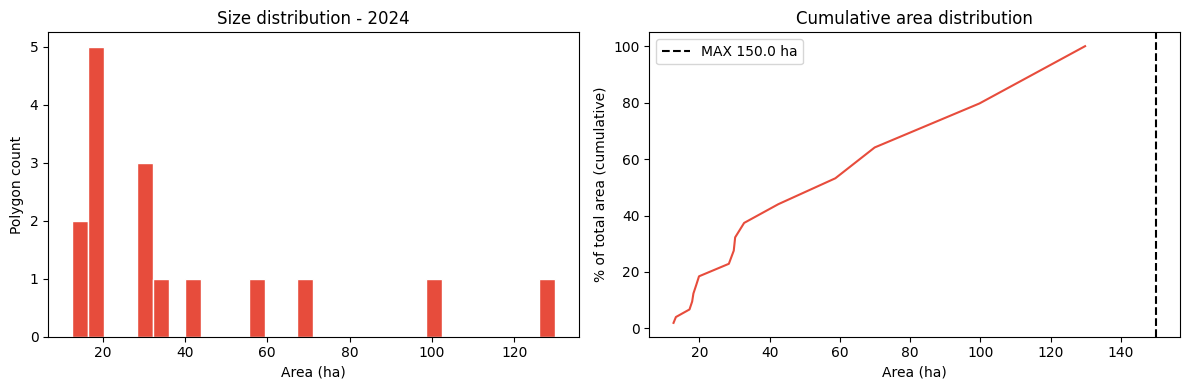

In [15]:
# -- Descriptive stats of the exported GeoJSON --------------------------------
if os.path.exists(out_2024):
    with open(out_2024) as f:
        data = json.load(f)

    areas = sorted(ft['properties'].get('area_m2', 0) / 10_000 for ft in data['features'])

    if areas:
        print(f'=== OBIA {TRAINING_YEAR} summary ===')
        print(f'  Polygons        : {len(areas)}')
        print(f'  Total area      : {sum(areas):,.1f} ha')
        print(f'  Largest         : {areas[-1]:,.1f} ha')
        print(f'  Median          : {areas[len(areas)//2]:,.1f} ha')
        print(f'  Threshold       : {CONFIDENCE_THRESHOLD}')
        print(f'  Area filter     : [{MIN_AREA_HA}, {MAX_AREA_HA}] ha')

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.hist(areas, bins=30, color='#e74c3c', edgecolor='white')
        ax1.set_xlabel('Area (ha)')
        ax1.set_ylabel('Polygon count')
        ax1.set_title(f'Size distribution - {TRAINING_YEAR}')

        cumsum = np.cumsum(areas)
        ax2.plot(areas, cumsum / cumsum[-1] * 100, color='#e74c3c')
        ax2.axvline(x=MAX_AREA_HA, color='black', linestyle='--', label=f'MAX {MAX_AREA_HA} ha')
        ax2.set_xlabel('Area (ha)')
        ax2.set_ylabel('% of total area (cumulative)')
        ax2.set_title('Cumulative area distribution')
        ax2.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('No polygons in the exported GeoJSON - try lowering CONFIDENCE_THRESHOLD.')
else:
    print(f'GeoJSON not found at {out_2024}')


---
## 9b - Interactive size filter (optional)

Drag the slider to preview which polygons survive different **minimum-area**
cutoffs. Left = the kept polygons; right = the size histogram with your cutoff
line, so you can see where the "little outsiders" sit and how many you'd drop.

It reads the polygons you already exported (no GEE, instant). Once you pick a
size, set `MIN_AREA_HA` in Section 1 and re-run Section 9 to export it.

> Note: the exported file already dropped everything below the current
> `MIN_AREA_HA`, so you can only explore *upward* from it. To also see smaller
> polygons, lower `MIN_AREA_HA` in Section 1, re-run Section 9 once, then come back.


In [16]:
import geopandas as gpd
import ipywidgets as widgets
from IPython.display import display

# Read the polygons you just exported (local, no GEE).
gdf = gpd.read_file(out_2024)
if 'area_ha' not in gdf.columns:
    gdf['area_ha'] = gdf['area_m2'] / 10_000

a_min, a_max = float(gdf['area_ha'].min()), float(gdf['area_ha'].max())
print(f'{len(gdf)} polygons | size range {a_min:.2f} - {a_max:.1f} ha '
      f'(current MIN_AREA_HA = {MIN_AREA_HA})')

size_slider = widgets.FloatSlider(
    value=max(MIN_AREA_HA, a_min), min=round(a_min, 2), max=min(15.0, a_max),
    step=0.1, description='Min area (ha):', continuous_update=False,
    readout_format='.1f', layout=widgets.Layout(width='550px'),
)
out_size = widgets.Output()


def render_size(min_ha):
    with out_size:
        out_size.clear_output(wait=True)
        kept = gdf[gdf['area_ha'] >= min_ha]
        dropped = len(gdf) - len(kept)
        fig, (axm, axh) = plt.subplots(1, 2, figsize=(14, 6),
                                       gridspec_kw={'width_ratios': [1.4, 1]})
        if len(kept):
            kept.plot(ax=axm, color='#e74c3c', edgecolor='none')
        axm.set_aspect('equal')
        axm.set_title(f'Min {min_ha:.1f} ha -> {len(kept)} kept, {dropped} dropped')
        axm.set_xlabel('Longitude'); axm.set_ylabel('Latitude')

        axh.hist(gdf['area_ha'], bins=40, color='#bbb', edgecolor='white')
        axh.axvline(min_ha, color='#e74c3c', linestyle='--', label=f'cutoff {min_ha:.1f} ha')
        axh.set_xlabel('Polygon area (ha)'); axh.set_ylabel('count')
        axh.set_title(f'Total kept area: {kept["area_ha"].sum():.0f} ha')
        axh.legend()
        plt.tight_layout(); plt.show()


size_slider.observe(
    lambda ch: render_size(ch['new']) if ch['name'] == 'value' else None, names='value')
display(size_slider, out_size)
render_size(size_slider.value)
print('Pick a cutoff, then set MIN_AREA_HA in Section 1 and re-run Section 9 to export it.')

16 polygons | size range 12.61 - 129.8 ha (current MIN_AREA_HA = 12.0)


FloatSlider(value=12.61, continuous_update=False, description='Min area (ha):', layout=Layout(width='550px'), …

Output()

Pick a cutoff, then set MIN_AREA_HA in Section 1 and re-run Section 9 to export it.


---
## 10 - Tuning guide

Adjust **in Section 1**. Threshold/smoothing changes only need Sections 7-9;
sampling/training changes need Sections 5-9 (retrain).

| Symptom | Fix |
|---------|-----|
| Some false positives (formal flagged) | **Raise** `CONFIDENCE_THRESHOLD` (0.55-0.70), or add `formal` polygons over the offender |
| Real settlements missed | **Lower** `CONFIDENCE_THRESHOLD` (0.40-0.50) |
| Park / savanna / bare land flagged | Keep `USE_BACKGROUND = True` (covers empty land) |
| Worried about pseudo-negative noise | Add `formal`/`other` polygons, then set `USE_BACKGROUND = False` |
| Noisy / speckled output | **Raise** `SMOOTH_RADIUS_PX` (4-5) |
| Borders too blobby | **Lower** `SMOOTH_RADIUS_PX` (2) |
| Broad over-detection persists | **Raise** `NEG_POS_RATIO` (5-6) |
| Too few detections everywhere | **Lower** `NEG_POS_RATIO` (2-3) |
| Section 6 diagnostic reversed | Set `INVERT_PROB = True` in Section 7 |

**Workflow for fixing a specific formal estate:** draw `formal` polygons over it
in `training_zones_v2.geojson` (they're always kept in full), re-run Sections
5-9. Toggle `USE_BACKGROUND` off once your polygons cover both formal *and*
empty land — on if the park starts leaking back in.


---
## 11 - Apply to past years (optional)

Once 2024 looks right, classify 2020 with the same model, threshold and
smoothing. Valid because the 18 features are computed identically and
informal-settlement signatures change slowly over a few years.


In [17]:
PAST_YEARS = [2020]   # add 2022 if needed

for year_past in PAST_YEARS:
    print(f'\nProcessing {year_past} (model trained on {TRAINING_YEAR})...')
    classified_past, _ = classify_year_obia(year_past, nairobi_boundary)
    informal_fc_past = raster_to_informal_polygons(classified_past, nairobi_boundary)
    n = informal_fc_past.size().getInfo()
    print(f'  {n} informal polygons [{MIN_AREA_HA}-{MAX_AREA_HA} ha]')

    stem_past        = f'informal_settlements_obia_{year_past}'
    out_past, v_past = versioned_path(RESULTS_DIR, stem_past)
    webapp_past      = os.path.join(WEBAPP_MAPS_DIR, f'{stem_past}.geojson')

    if export_with_retry(informal_fc_past, out_past):
        print(f'  Archived -> {out_past}  (version v{v_past})')
        shutil.copy(out_past, webapp_past)
        print(f'  Webapp   -> {webapp_past}  (stable name)')

print('\nAll past years done.')


Processing 2020 (model trained on 2024)...
  [2020] Building composite...
  [Loading Sentinel-2 composite for 2020]
  [Computing spectral indices]
  [Computing GLCM texture features]
  [2020] Predicting P(informal)...
  [2020] Smoothing + threshold 0.68...
  27 informal polygons [12.0-150.0 ha]
  Archived -> ../results/exposure\informal_settlements_obia_2020_v6.geojson  (version v6)
  Webapp   -> ../webapp/public/maps\informal_settlements_obia_2020.geojson  (stable name)

All past years done.
